In [1]:
import pandas as pd
import numpy as np

RAW1 = "data/raw_data1.csv"
RAW2 = "data/raw_data2.csv"

df1 = pd.read_csv(RAW1)
df2 = pd.read_csv(RAW2)

print("RAW1 shape:", df1.shape)
print("RAW2 shape:", df2.shape)

RAW1 shape: (174871, 26)
RAW2 shape: (64055, 4)


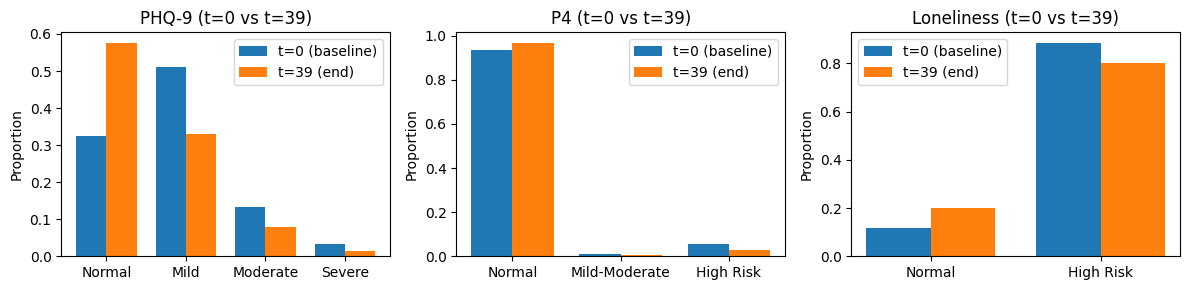

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SURVEY_PHQ9       = "PHQ-9"
SURVEY_P4         = "P4"
SURVEY_LONELINESS = "Loneliness"

def _to_int(x):
    try:
        return int(str(x).strip())
    except Exception:
        return np.nan

def load_surveys(raw2_csv: str, id_col: str = "menti_seq") -> pd.DataFrame:
    df = pd.read_csv(raw2_csv)
    df["srvy_result"] = df["srvy_result"].apply(_to_int)
    df["reg_date"] = pd.to_datetime(df["reg_date"], errors="coerce")
    return df[[id_col, "srvy_name", "srvy_result", "reg_date"]].dropna(subset=["srvy_name"]).reset_index(drop=True)

def first_last_per_pid(sdf: pd.DataFrame, survey_name: str, id_col: str = "menti_seq"):
    g = sdf[sdf["srvy_name"] == survey_name].sort_values([id_col, "reg_date"])
    # pid별 first/last
    first = g.groupby(id_col)["srvy_result"].first()
    last  = g.groupby(id_col)["srvy_result"].last()
    out = pd.DataFrame({"t0": first, "t39": last}).dropna()
    out["t0"] = out["t0"].astype(int)
    out["t39"] = out["t39"].astype(int)
    return out

# ====== plot helper ======
def plot_baseline_vs_end_bars(df_t0t40: pd.DataFrame, title: str, x_labels: list[str]):
    """
    df_t0t40: columns ['t0','t39'] with integer categories
    x_labels: category labels in order of 0..K-1 (or explicit mapping)
    """
    # 카테고리 0..K-1 기준으로 proportion 계산
    K = len(x_labels)
    p0 = df_t0t40["t0"].value_counts(normalize=True).reindex(range(K), fill_value=0).values
    p1 = df_t0t40["t39"].value_counts(normalize=True).reindex(range(K), fill_value=0).values

    x = np.arange(K)
    w = 0.38

    plt.bar(x - w/2, p0, width=w, label="t=0 (baseline)")
    plt.bar(x + w/2, p1, width=w, label="t=39 (end)")

    plt.xticks(x, x_labels)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend()

# ====== MAIN ======
RAW2 = "data/raw_data2.csv"   # 네 경로에 맞게 수정
ID_COL = "menti_seq"

sdf = load_surveys(RAW2, id_col=ID_COL)

# (필요하면) 네 코드처럼 3설문 모두 존재하는 cohort로 제한하고 싶으면 아래 활성화
# -> 주간 40주 다 가진 cohort(batch.stats["patients"])가 있다면 그 pid로 필터링하면 가장 정확함.
# keep_pids = set(batch.stats["patients"])
# sdf = sdf[sdf[ID_COL].isin(keep_pids)].copy()

phq = first_last_per_pid(sdf, SURVEY_PHQ9, id_col=ID_COL)
p4  = first_last_per_pid(sdf, SURVEY_P4, id_col=ID_COL)
lon = first_last_per_pid(sdf, SURVEY_LONELINESS, id_col=ID_COL)

# 라벨 (네 baseline plot과 맞춰서 조정)
phq_labels = ["Normal", "Mild", "Moderate", "Severe"]      # 0,1,2,3
p4_labels  = ["Normal", "Mild-Moderate", "High Risk"]      # 0,1,2
lon_labels = ["Normal", "High Risk"]                       # 0,1

plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plot_baseline_vs_end_bars(phq, "PHQ-9 (t=0 vs t=39)", phq_labels)

plt.subplot(1, 3, 2)
plot_baseline_vs_end_bars(p4, "P4 (t=0 vs t=39)", p4_labels)

plt.subplot(1, 3, 3)
plot_baseline_vs_end_bars(lon, "Loneliness (t=0 vs t=39)", lon_labels)

plt.tight_layout()
plt.show()


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os
from approach3 import build_dataset, ensure_dir

RAW1 = "data/raw_data1.csv"
RAW2 = "data/raw_data2.csv"
OUT  = ensure_dir("figs_phq_multi_attn")

batch = build_dataset(RAW1, RAW2, T=40, outdir=OUT, seed=42)


OUT = "figs_phq_multi_attn"
os.makedirs(OUT, exist_ok=True)

labels = ["improved", "unchanged", "worsened"]

def plot_delta_dist(dY, title, fname, idx=None):
    # torch → numpy
    if hasattr(dY, "detach"):
        dY = dY.detach().cpu().numpy()

    if idx is not None:
        dY = dY[idx]

    # label 없는 것 제거
    dY = dY[dY >= 0]

    counts = np.bincount(dY, minlength=3)[:3]
    probs = counts / counts.sum()

    plt.figure(figsize=(4, 3))
    plt.bar(range(3), probs)
    plt.xticks(range(3), labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Proportion")
    plt.title(f"{title}")

    for i, v in enumerate(probs):
        plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, fname), dpi=150)
    plt.show()


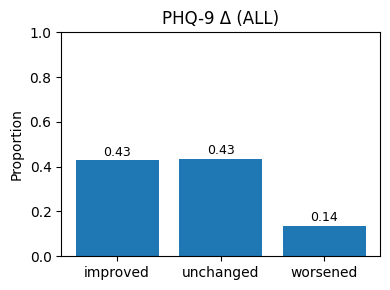

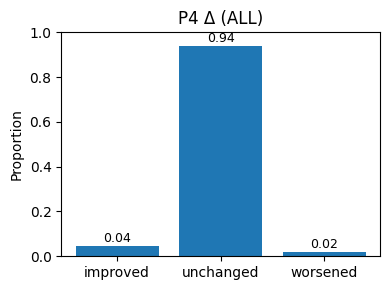

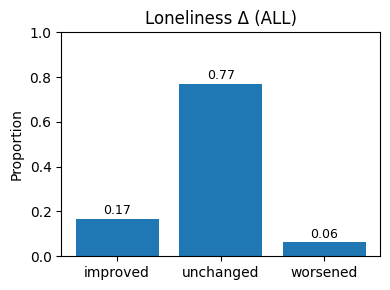

In [32]:
%matplotlib inline
plot_delta_dist(batch.dY_phq, "PHQ-9 Δ (ALL)", "dist_PHQ_all.png")
plot_delta_dist(batch.dY_p4,  "P4 Δ (ALL)",    "dist_P4_all.png")
plot_delta_dist(batch.dY_lon, "Loneliness Δ (ALL)", "dist_Lon_all.png")


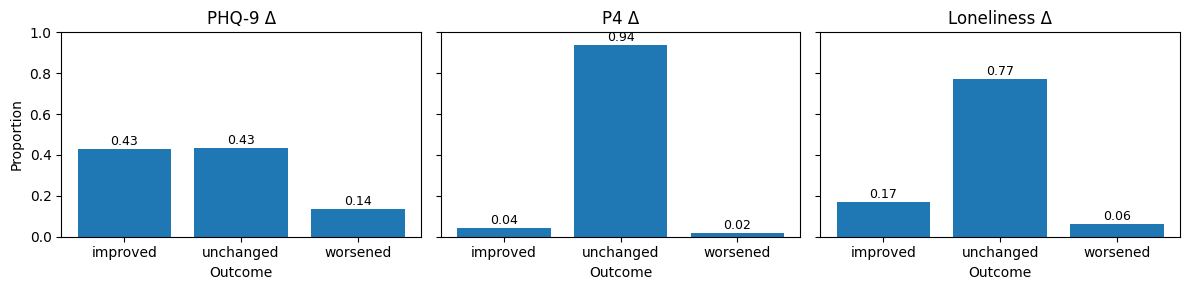

In [34]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os

OUT = "figs_phq_multi_attn"
os.makedirs(OUT, exist_ok=True)

labels = ["improved", "unchanged", "worsened"]

def get_probs(dY):
    if hasattr(dY, "detach"):
        dY = dY.detach().cpu().numpy()
    dY = dY[dY >= 0]
    counts = np.bincount(dY, minlength=3)[:3]
    probs = counts / counts.sum()
    return probs, counts.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

datasets = [
    ("PHQ-9 Δ", batch.dY_phq),
    ("P4 Δ", batch.dY_p4),
    ("Loneliness Δ", batch.dY_lon),
]

for ax, (title, dY) in zip(axes, datasets):
    probs, n = get_probs(dY)
    ax.bar(range(3), probs)
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{title}")
    ax.set_xlabel("Outcome")

    for i, v in enumerate(probs):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

axes[0].set_ylabel("Proportion")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "delta_dist_all_horizontal.png"), dpi=150)
plt.show()


In [21]:
import numpy as np

def verify_participant_count(batch, expected_n=2000, verbose=True):
    """
    batch에 포함된 participant 수(전체/유니크)와
    train/val split 크기 및 겹침 여부를 점검한다.
    """
    # 1) 전체 B
    B_tensor = int(batch.S.size(0))

    # 2) stats patients
    if "patients" not in batch.stats:
        raise ValueError("batch.stats['patients']가 없습니다. build_dataset에서 stats에 patients를 넣었는지 확인하세요.")

    patients = np.asarray(batch.stats["patients"])
    B_stats = int(len(patients))

    # 3) 유니크 수
    uniq = np.unique(patients)
    B_uniq = int(len(uniq))

    # 4) split 크기 및 겹침 체크
    idx_tr = np.asarray(batch.idx_tr)
    idx_val = np.asarray(batch.idx_val)

    n_tr = int(len(idx_tr))
    n_val = int(len(idx_val))
    inter = np.intersect1d(idx_tr, idx_val)
    n_inter = int(len(inter))

    # 5) idx 범위 sanity
    if (idx_tr.min() < 0) or (idx_val.min() < 0) or (idx_tr.max() >= B_tensor) or (idx_val.max() >= B_tensor):
        raise ValueError("idx_tr/idx_val에 batch 범위를 벗어나는 인덱스가 있습니다.")

    # 6) 결과 리포트
    report = {
        "B_tensor": B_tensor,
        "B_stats": B_stats,
        "B_unique": B_uniq,
        "expected": expected_n,
        "match_expected_unique": (B_uniq == expected_n),
        "train_size": n_tr,
        "val_size": n_val,
        "train_val_overlap": n_inter,
    }

    if verbose:
        print("===== Participant Count Check =====")
        print(f"B from batch.S.size(0): {B_tensor}")
        print(f"B from len(batch.stats['patients']): {B_stats}")
        print(f"Unique patients: {B_uniq}")
        print(f"Expected unique: {expected_n}  ->  {'OK' if B_uniq == expected_n else 'NOT OK'}")
        print("----- Split Check -----")
        print(f"train n: {n_tr}, val n: {n_val}, overlap: {n_inter}  ->  {'OK' if n_inter == 0 else 'NOT OK'}")
        print("===================================\n")

    return report


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def service_heatmap_from_batch(
    batch,
    split="all",          # "all" | "train" | "val"
    chunk_size=256,
    use_binary=True,      # S가 이미 0/1이어도 안전하게 (S>0)로 이진화
    title_suffix="",
    expected_n=2000,      # <-- 추가: 기대 인원
    run_verify=True,      # <-- 추가: 검증 실행 여부
):
    device = batch.S.device

    # -------------------------
    # 0) 2000명 검증
    # -------------------------
    if run_verify:
        verify_participant_count(batch, expected_n=expected_n, verbose=True)

    # -------------------------
    # 1) 어떤 환자 인덱스를 쓸지
    # -------------------------
    if split == "train":
        idx = batch.idx_tr
    elif split == "val":
        idx = batch.idx_val
    elif split == "all":
        idx = np.arange(batch.S.size(0))
    else:
        raise ValueError("split must be one of: ['all','train','val']")

    idx = np.asarray(idx)
    B = len(idx)

    # -------------------------
    # 2) 환자 id는 stats['patients']에 있음
    # -------------------------
    patients = np.asarray(batch.stats["patients"])
    pid_sel = patients[idx]  # 필요하면 같이 저장/디버깅용

    # (NEW) split별 유니크 pid 수 확인
    pid_unique = np.unique(pid_sel)
    print(f"[CHECK] split='{split}' -> B={B}, unique_pid={len(pid_unique)}")

    # 서비스 컬럼 이름
    service_cols = batch.stats.get("service_cols", [f"service{i+1}" for i in range(batch.S.size(-1))])

    # -------------------------
    # 3) improved vs else 라벨 (ΔPHQ 기준)
    # -------------------------
    dY = batch.dY_phq[idx]  # (B,)
    dY_cpu = dY.detach().to("cpu").numpy()
    imp_mask_np = (dY_cpu == 0)
    else_mask_np = (dY_cpu != 0) & (dY_cpu >= 0)

    n_imp = int(imp_mask_np.sum())
    n_else = int(else_mask_np.sum())
    if n_imp == 0 or n_else == 0:
        raise RuntimeError(f"Group empty: n_imp={n_imp}, n_else={n_else}. split={split}")

    # -------------------------
    # 4) chunk 누적 합 (t, service)
    # -------------------------
    T = batch.S.size(1)
    d_s = batch.S.size(2)

    sum_imp  = torch.zeros((T, d_s), dtype=torch.float32, device="cpu")
    sum_else = torch.zeros((T, d_s), dtype=torch.float32, device="cpu")

    # chunk loop
    for st in range(0, B, chunk_size):
        ed = min(st + chunk_size, B)
        sub_idx = idx[st:ed]

        S = batch.S[sub_idx]  # (b,T,16) on device
        if use_binary:
            S = (S > 0).float()

        S_cpu = S.detach().to("cpu")  # (b,T,d_s)

        # 라벨 마스크
        imp_m = torch.from_numpy(imp_mask_np[st:ed]).to("cpu")   # (b,)
        els_m = torch.from_numpy(else_mask_np[st:ed]).to("cpu")  # (b,)

        if imp_m.any():
            sum_imp += S_cpu[imp_m].sum(dim=0)
        if els_m.any():
            sum_else += S_cpu[els_m].sum(dim=0)

    H_imp  = (sum_imp  / n_imp).T.numpy()    # (d_s,T)
    H_else = (sum_else / n_else).T.numpy()   # (d_s,T)
    H_diff = H_imp - H_else

    # -------------------------
    # 5) plot
    # -------------------------
    x_ticks = np.arange(0, T, 5)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

    im0 = axes[0].imshow(H_imp, aspect="auto", interpolation="nearest", origin="lower")
    axes[0].set_title(f"Service usage: PHQ improved (n={n_imp}){title_suffix}")
    axes[0].set_xlabel("timestep t")
    axes[0].set_ylabel("service")
    axes[0].set_yticks(np.arange(len(service_cols)))
    axes[0].set_yticklabels(service_cols)
    axes[0].set_xticks(x_ticks)
    plt.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.02)

    im1 = axes[1].imshow(H_else, aspect="auto", interpolation="nearest", origin="lower")
    axes[1].set_title(f"Service usage: PHQ else (n={n_else}){title_suffix}")
    axes[1].set_xlabel("timestep t")
    axes[1].set_yticks(np.arange(len(service_cols)))
    axes[1].set_yticklabels(service_cols)
    axes[1].set_xticks(x_ticks)
    plt.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.02)

    im2 = axes[2].imshow(H_diff, aspect="auto", interpolation="nearest", origin="lower")
    axes[2].set_title("Difference (improved − else)")
    axes[2].set_xlabel("timestep t")
    axes[2].set_yticks(np.arange(len(service_cols)))
    axes[2].set_yticklabels(service_cols)
    axes[2].set_xticks(x_ticks)
    plt.colorbar(im2, ax=axes[2], fraction=0.03, pad=0.02)

    plt.show()

    return {
        "H_imp": H_imp,
        "H_else": H_else,
        "H_diff": H_diff,
        "n_imp": n_imp,
        "n_else": n_else,
        "pid_sel": pid_sel,
        "pid_unique_n": len(pid_unique),   # (NEW)
        "B_split": B,                      # (NEW)
        "service_cols": service_cols,
        "T": int(T),
    }


===== Participant Count Check =====
B from batch.S.size(0): 2000
B from len(batch.stats['patients']): 2000
Unique patients: 2000
Expected unique: 2000  ->  OK
----- Split Check -----
train n: 1600, val n: 400, overlap: 0  ->  OK

[CHECK] split='all' -> B=2000, unique_pid=2000


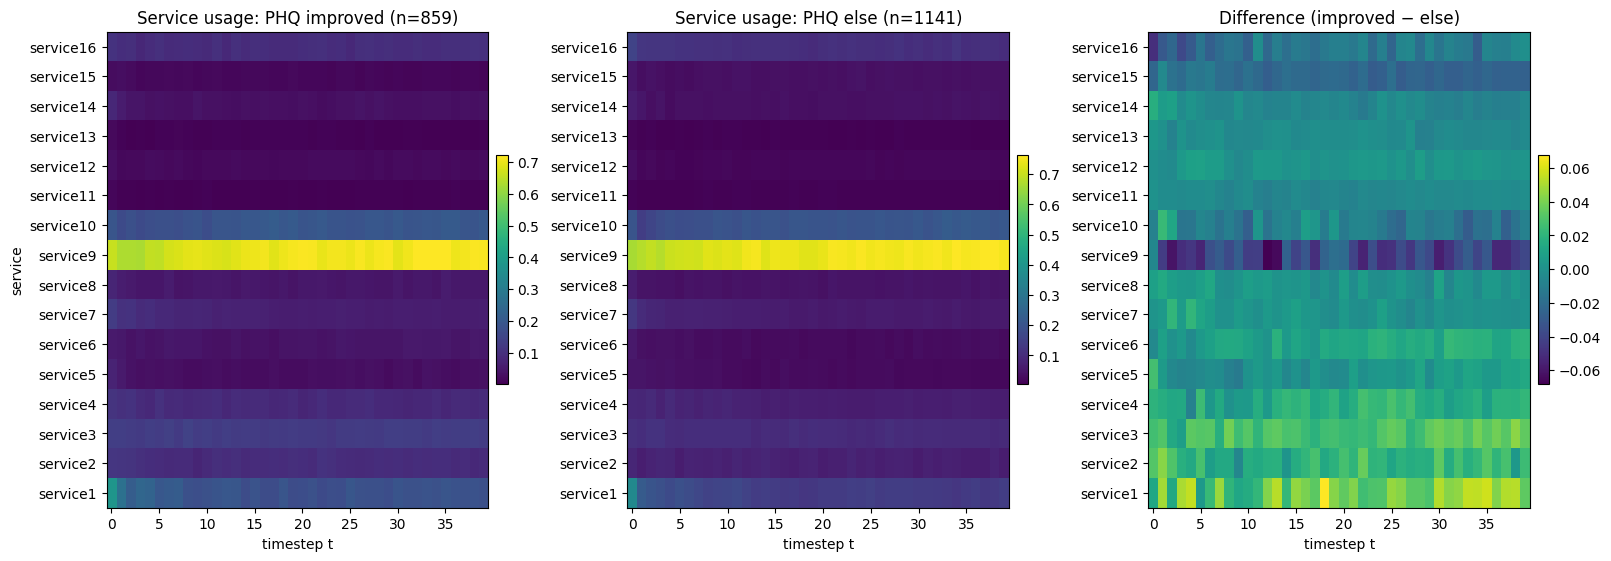

Returned: {'B_split': 2000, 'pid_unique_n': 2000, 'n_imp': 859, 'n_else': 1141, 'T': 40}


In [ ]:

out = service_heatmap_from_batch(
    batch,
    split="all",
    chunk_size=256,
    use_binary=True,
    expected_n=2000,
    run_verify=True
)

print("Returned:", {k: out[k] for k in ["B_split", "pid_unique_n", "n_imp", "n_else", "T"]})


[CHECK] batch.stats['patients'] len: 2000
[CHECK] unique cohort size: 2000
[OK] weekly cohort (unique): 2000
[OK] survey cohort (unique): 2000
[OK] pids with PHQ label: 2000
[OK] weekly pids after join: 2000
[INFO] cohort missing PHQ label: 0


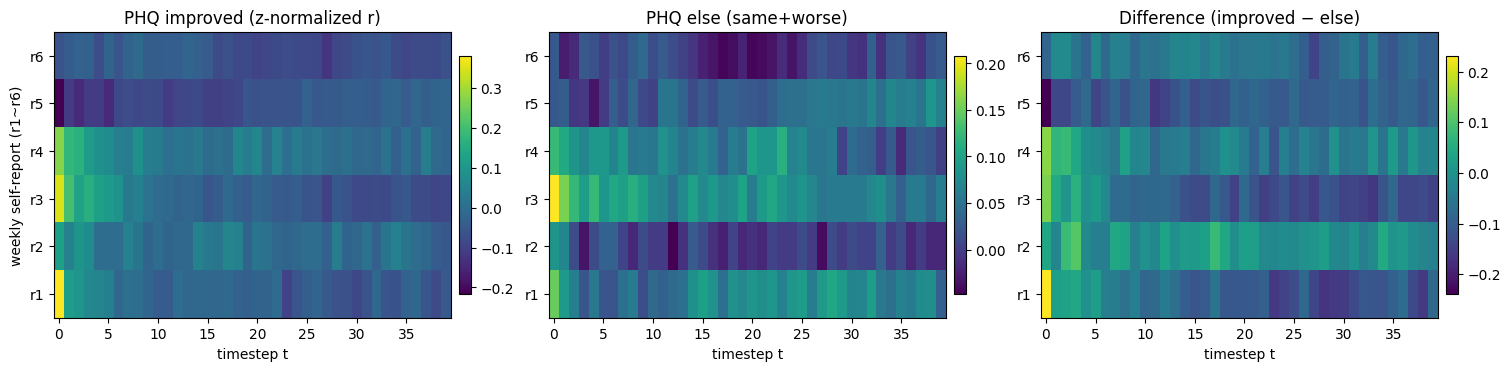

[PHQ label distribution]
 label_imp
else        1141
improved     859
Name: count, dtype: int64
[Weekly reflected pid count]
 label_imp
else        1141
improved     859
Name: menti_seq, dtype: int64
[SUMMARY] cohort_unique=2000 | with_PHQ=2000 | weekly_after_join=2000 | final_merged=2000


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) cohort 정합: "2000명 코호트" = batch.stats["patients"]
# =========================
ID_COL = "menti_seq"

cohort_ids = np.asarray(batch.stats["patients"])
cohort_unique = np.unique(cohort_ids)

print("[CHECK] batch.stats['patients'] len:", len(cohort_ids))
print("[CHECK] unique cohort size:", len(cohort_unique))

# 기대값 체크 (원하면 assert로 강제 가능)
# assert len(cohort_unique) == 2000, f"Unique cohort != 2000 (got {len(cohort_unique)})"

keep_set = set(cohort_unique)

# weekly / survey 둘 다 2000명 코호트로 제한
sdf_k  = sdf[sdf[ID_COL].isin(keep_set)].copy()
dfC_k  = dfC_norm[dfC_norm[ID_COL].isin(keep_set)].copy()

print("[OK] weekly cohort (unique):", dfC_k[ID_COL].nunique())
print("[OK] survey cohort (unique):", sdf_k[ID_COL].nunique())

# =========================
# 1) PHQ first/last로 improved vs else 라벨 만들기
#    improved: t_last - t_first < 0
#    else:     t_last - t_first >= 0
# =========================
def phq_first_last_label(sdf_long: pd.DataFrame, id_col: str, survey_name: str):
    g = sdf_long[sdf_long["srvy_name"] == survey_name].sort_values([id_col, "reg_date"])
    first = g.groupby(id_col)["srvy_result"].first()
    last  = g.groupby(id_col)["srvy_result"].last()
    out = pd.DataFrame({"t0": first, "t39": last}).dropna()

    # 안전 캐스팅 (srvy_result가 float/string이어도 처리)
    out["t0"] = out["t0"].astype(int)
    out["t39"] = out["t39"].astype(int)

    out["d"] = out["t39"] - out["t0"]
    out["label_imp"] = (out["d"] < 0).astype(int)  # 1=improved, 0=else
    return out

phq_t0t39 = phq_first_last_label(sdf_k, ID_COL, SURVEY_PHQ9)

# PHQ 라벨이 존재하는 pid만 weekly에 남김
valid_pids = set(phq_t0t39.index)
dfC_join = dfC_k[dfC_k[ID_COL].isin(valid_pids)].copy()

print("[OK] pids with PHQ label:", len(valid_pids))
print("[OK] weekly pids after join:", dfC_join[ID_COL].nunique())

# (중요) 2000명 중 PHQ 라벨이 없는 사람 수 확인
missing_phq = keep_set - valid_pids
print("[INFO] cohort missing PHQ label:", len(missing_phq))

# =========================
# 2) improved / else 그룹별 (t, r) mean → heatmap matrix (6×40)
# =========================
df_merge = dfC_join.merge(
    phq_t0t39[["label_imp"]],
    left_on=ID_COL,
    right_index=True,
    how="inner"
)

# group mean over time
H_imp_df = (
    df_merge[df_merge["label_imp"] == 1]
    .groupby("t")[r_cols].mean()
    .reindex(range(T))
)
H_else_df = (
    df_merge[df_merge["label_imp"] == 0]
    .groupby("t")[r_cols].mean()
    .reindex(range(T))
)

H_imp  = H_imp_df.T.values   # (6,40)
H_else = H_else_df.T.values  # (6,40)
H_diff = H_imp - H_else

# =========================
# 3) plot (imp / else / diff)
# =========================
x_ticks = np.arange(0, T, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)

im0 = axes[0].imshow(H_imp, aspect="auto", interpolation="nearest", origin="lower")
axes[0].set_title("PHQ improved (z-normalized r)")
axes[0].set_xlabel("timestep t")
axes[0].set_ylabel("weekly self-report (r1~r6)")
axes[0].set_yticks(np.arange(len(r_cols)))
axes[0].set_yticklabels(r_cols)
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels([str(i) for i in x_ticks])
plt.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.02)

im1 = axes[1].imshow(H_else, aspect="auto", interpolation="nearest", origin="lower")
axes[1].set_title("PHQ else (same+worse)")
axes[1].set_xlabel("timestep t")
axes[1].set_yticks(np.arange(len(r_cols)))
axes[1].set_yticklabels(r_cols)
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels([str(i) for i in x_ticks])
plt.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.02)

im2 = axes[2].imshow(H_diff, aspect="auto", interpolation="nearest", origin="lower")
axes[2].set_title("Difference (improved − else)")
axes[2].set_xlabel("timestep t")
axes[2].set_yticks(np.arange(len(r_cols)))
axes[2].set_yticklabels(r_cols)
axes[2].set_xticks(x_ticks)
axes[2].set_xticklabels([str(i) for i in x_ticks])
plt.colorbar(im2, ax=axes[2], fraction=0.03, pad=0.02)

plt.show()

# =========================
# 4) 그룹 크기/분포 체크
# =========================
cnt = phq_t0t39["label_imp"].value_counts().rename(index={1:"improved", 0:"else"})
print("[PHQ label distribution]\n", cnt)

cnt2 = df_merge.groupby("label_imp")[ID_COL].nunique().rename(index={1:"improved", 0:"else"})
print("[Weekly reflected pid count]\n", cnt2)

# (옵션) 2000명 코호트 대비 최종 반영 인원 요약
final_unique = df_merge[ID_COL].nunique()
print(f"[SUMMARY] cohort_unique={len(cohort_unique)} | with_PHQ={len(valid_pids)} | weekly_after_join={dfC_join[ID_COL].nunique()} | final_merged={final_unique}")


[CHECK] batch.stats['patients'] len: 2000
[CHECK] unique cohort size: 2000
[OK] survey pids after cohort filter: 2000
[INFO] dropped survey pids: 4058
[PHQ] pids with first/last: 2000
[P4 ] pids with first/last: 2000
[LON] pids with first/last: 2000


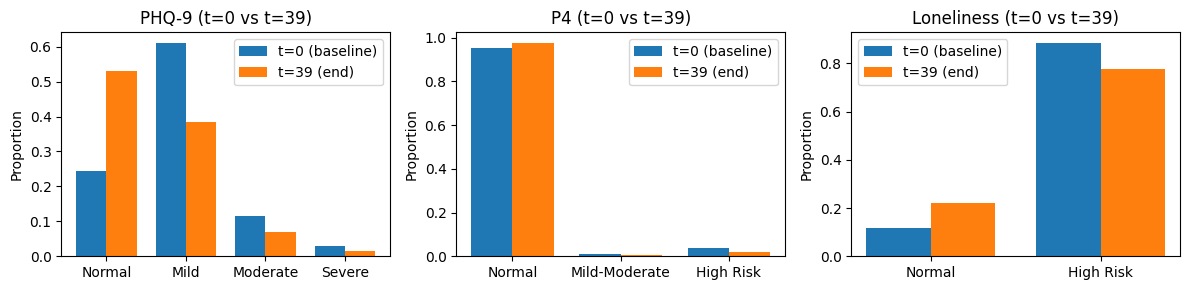

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SURVEY_PHQ9       = "PHQ-9"
SURVEY_P4         = "P4"
SURVEY_LONELINESS = "Loneliness"

def _to_int(x):
    try:
        return int(str(x).strip())
    except Exception:
        return np.nan

def load_surveys(raw2_csv: str, id_col: str = "menti_seq") -> pd.DataFrame:
    df = pd.read_csv(raw2_csv)
    df["srvy_result"] = df["srvy_result"].apply(_to_int)
    df["reg_date"] = pd.to_datetime(df["reg_date"], errors="coerce")
    return (
        df[[id_col, "srvy_name", "srvy_result", "reg_date"]]
        .dropna(subset=["srvy_name"])
        .reset_index(drop=True)
    )

def first_last_per_pid(sdf: pd.DataFrame, survey_name: str, id_col: str = "menti_seq"):
    g = sdf[sdf["srvy_name"] == survey_name].sort_values([id_col, "reg_date"])
    first = g.groupby(id_col)["srvy_result"].first()
    last  = g.groupby(id_col)["srvy_result"].last()
    out = pd.DataFrame({"t0": first, "t39": last}).dropna()
    out["t0"] = out["t0"].astype(int)
    out["t39"] = out["t39"].astype(int)
    return out

# ====== plot helper ======
def plot_baseline_vs_end_bars(df_t0t40: pd.DataFrame, title: str, x_labels: list[str]):
    """
    df_t0t40: columns ['t0','t39'] with integer categories
    x_labels: category labels in order of 0..K-1
    """
    K = len(x_labels)
    p0 = df_t0t40["t0"].value_counts(normalize=True).reindex(range(K), fill_value=0).values
    p1 = df_t0t40["t39"].value_counts(normalize=True).reindex(range(K), fill_value=0).values

    x = np.arange(K)
    w = 0.38

    plt.bar(x - w/2, p0, width=w, label="t=0 (baseline)")
    plt.bar(x + w/2, p1, width=w, label="t=39 (end)")

    plt.xticks(x, x_labels)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend()

# ====== MAIN ======
RAW2 = "data/raw_data2.csv"   # 네 경로에 맞게 수정
ID_COL = "menti_seq"

# 1) 설문 로드
sdf_all = load_surveys(RAW2, id_col=ID_COL)

# 2) 2000명 코호트 = batch.stats["patients"] 로 제한
cohort_ids = np.asarray(batch.stats["patients"])
cohort_unique = np.unique(cohort_ids)

print("[CHECK] batch.stats['patients'] len:", len(cohort_ids))
print("[CHECK] unique cohort size:", len(cohort_unique))
# assert len(cohort_unique) == 2000, f"Unique cohort != 2000 (got {len(cohort_unique)})"

keep_pids = set(cohort_unique)

sdf = sdf_all[sdf_all[ID_COL].isin(keep_pids)].copy()

print("[OK] survey pids after cohort filter:", sdf[ID_COL].nunique())
print("[INFO] dropped survey pids:", sdf_all[ID_COL].nunique() - sdf[ID_COL].nunique())

# 3) first/last 계산 (2000명 기준)
phq = first_last_per_pid(sdf, SURVEY_PHQ9, id_col=ID_COL)
p4  = first_last_per_pid(sdf, SURVEY_P4, id_col=ID_COL)
lon = first_last_per_pid(sdf, SURVEY_LONELINESS, id_col=ID_COL)

# (옵션) 각 설문별로 라벨 가능한 pid 수 확인
print("[PHQ] pids with first/last:", phq.shape[0])
print("[P4 ] pids with first/last:", p4.shape[0])
print("[LON] pids with first/last:", lon.shape[0])

# 4) 라벨 (baseline plot용)
phq_labels = ["Normal", "Mild", "Moderate", "Severe"]      # 0,1,2,3
p4_labels  = ["Normal", "Mild-Moderate", "High Risk"]      # 0,1,2
lon_labels = ["Normal", "High Risk"]                       # 0,1

plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plot_baseline_vs_end_bars(phq, "PHQ-9 (t=0 vs t=39)", phq_labels)

plt.subplot(1, 3, 2)
plot_baseline_vs_end_bars(p4, "P4 (t=0 vs t=39)", p4_labels)

plt.subplot(1, 3, 3)
plot_baseline_vs_end_bars(lon, "Loneliness (t=0 vs t=39)", lon_labels)

plt.tight_layout()
plt.show()


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_baseline_comorbidity(batch, outdir: str):
    """
    Fig A: Baseline comorbidity heatmap
    - PHQ-9, P4, Loneliness baseline (t=0)
    - Spearman correlation
    """
    # ----- extract baseline values -----
    df = pd.DataFrame({
        "PHQ-9 (t0)": batch.y0_phq.cpu().numpy(),
        "P4 (t0)": batch.y0_p4.cpu().numpy(),
        "Loneliness (t0)": batch.y0_lon.cpu().numpy(),
    })

    # ----- correlation -----
    corr = df.corr(method="spearman")

    # ----- plot -----
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"label": "Spearman ρ"},
    )
    plt.title("Baseline comorbidity (t=0)")
    plt.tight_layout()

    fname = f"{outdir}/figA_baseline_comorbidity.png"
    plt.savefig(fname, dpi=150)
    plt.close()

    print(f"[SAVE] Fig A baseline comorbidity -> {fname}")
    return corr

def plot_delta_comorbidity(batch, outdir: str):
    """
    Fig B: Change-level comorbidity heatmap
    - ΔPHQ, ΔP4, ΔLon
    - Spearman correlation
    """
    # ----- Δ labels: 0=improved, 1=same, 2=worse -----
    df = pd.DataFrame({
        "ΔPHQ-9": batch.dY_phq.cpu().numpy(),
        "ΔP4": batch.dY_p4.cpu().numpy(),
        "ΔLoneliness": batch.dY_lon.cpu().numpy(),
    })

    # label 없는 샘플 제거 (안전)
    df = df[(df >= 0).all(axis=1)]

    # ----- correlation -----
    corr = df.corr(method="spearman")

    # ----- plot -----
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"label": "Spearman ρ"},
    )
    plt.title("Change-level comorbidity (Δ)")
    plt.tight_layout()

    fname = f"{outdir}/figB_delta_comorbidity.png"
    plt.savefig(fname, dpi=150)
    plt.close()

    print(f"[SAVE] Fig B delta comorbidity -> {fname}")
    return corr

# Fig A / Fig B
corr_base = plot_baseline_comorbidity(batch, outdir=OUT)
corr_delta = plot_delta_comorbidity(batch, outdir=OUT)

print("Baseline corr:\n", corr_base)
print("Delta corr:\n", corr_delta)


[SAVE] Fig A baseline comorbidity -> figs_phq_multi_attn/figA_baseline_comorbidity.png
[SAVE] Fig B delta comorbidity -> figs_phq_multi_attn/figB_delta_comorbidity.png
Baseline corr:
                  PHQ-9 (t0)   P4 (t0)  Loneliness (t0)
PHQ-9 (t0)         1.000000  0.163483         0.043273
P4 (t0)            0.163483  1.000000         0.067601
Loneliness (t0)    0.043273  0.067601         1.000000
Delta corr:
                ΔPHQ-9       ΔP4  ΔLoneliness
ΔPHQ-9       1.000000  0.057124     0.102739
ΔP4          0.057124  1.000000     0.129337
ΔLoneliness  0.102739  0.129337     1.000000


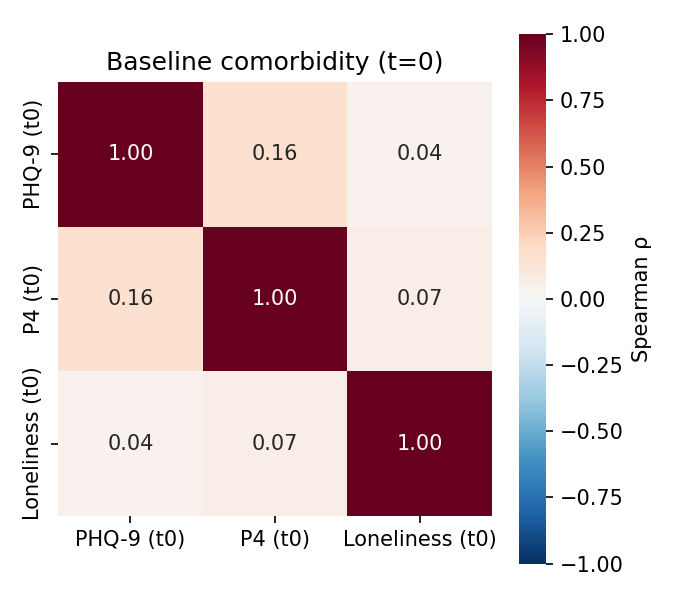

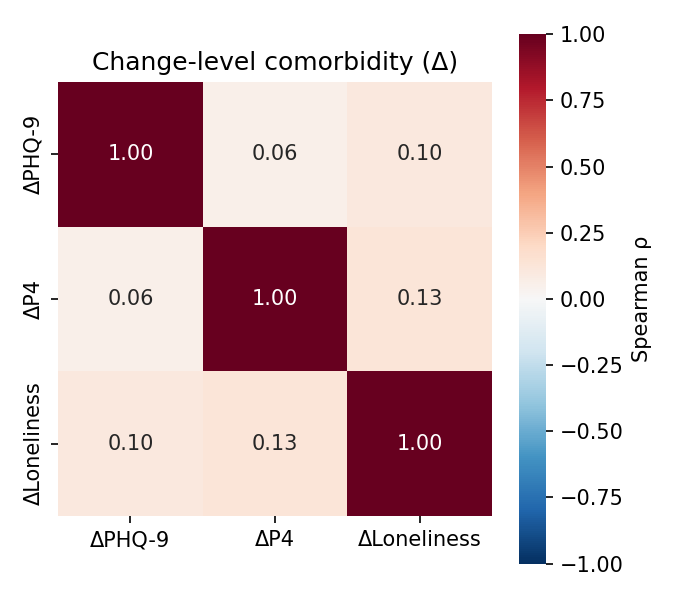

In [30]:
from IPython.display import Image, display

display(Image(filename=f"{OUT}/figA_baseline_comorbidity.png"))
display(Image(filename=f"{OUT}/figB_delta_comorbidity.png"))


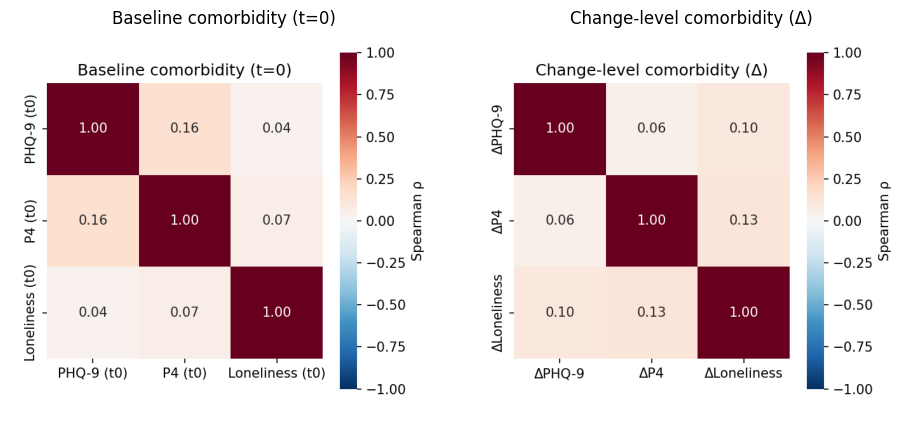

[SAVE] combined figure -> figs_phq_multi_attn/comorbidity_heatmaps.png


In [35]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 파일 경로
figA_path = f"{OUT}/figA_baseline_comorbidity.png"
figB_path = f"{OUT}/figB_delta_comorbidity.png"

# 이미지 로드
imgA = mpimg.imread(figA_path)
imgB = mpimg.imread(figB_path)

# Figure 생성
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))

axes[0].imshow(imgA)
axes[0].axis("off")
axes[0].set_title("Baseline comorbidity (t=0)")

axes[1].imshow(imgB)
axes[1].axis("off")
axes[1].set_title("Change-level comorbidity (Δ)")

plt.tight_layout()

# (선택) 하나의 png로 저장
out_path = f"{OUT}/comorbidity_heatmaps.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"[SAVE] combined figure -> {out_path}")


check cols: ['check1_value', 'check2_value', 'check3_value', 'check4_value', 'check5_value', 'check6_value']
n_rows raw: 174871 n_patients: 4933
after head(T=40): n_rows: 174871 n_patients: 4933
dropna rows: 0 remain: 174871
final rows used for corr: 174871


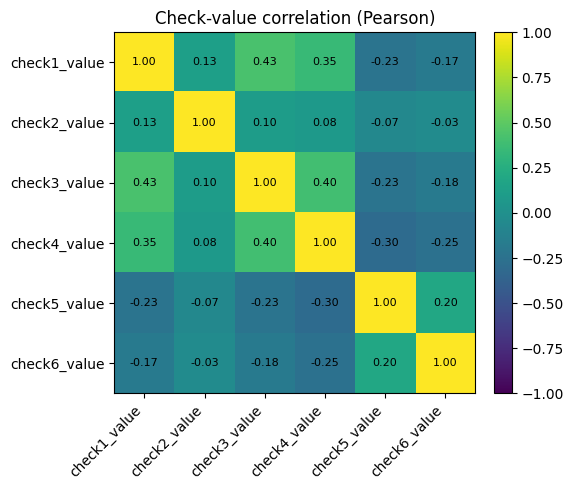

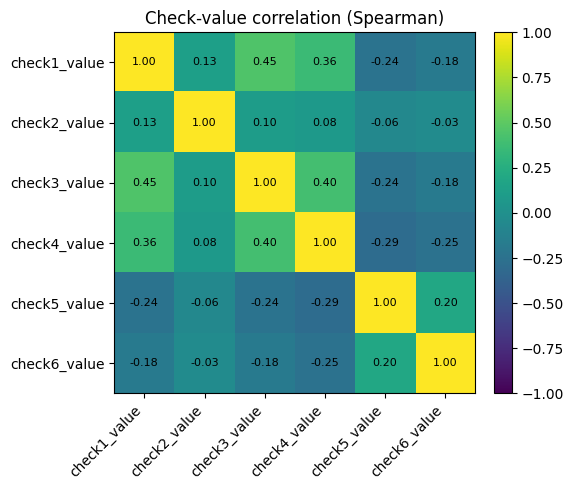

In [1]:
# ===== 0) imports =====
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _extract_int(s: str, default: int = 10**9) -> int:
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else default

def load_weekly(raw1_csv: str, id_col: str = "menti_seq", time_col: str = "reg_date"):
    df = pd.read_csv(raw1_csv)

    # 1) check*_value 우선
    check_val_cols = [c for c in df.columns if c.startswith("check") and c.endswith("_value")]
    check_val_cols = sorted(check_val_cols, key=_extract_int)

    # 2) 없으면 *_type 제외하고 check* 6개 선택
    if len(check_val_cols) == 0:
        cand = [c for c in df.columns if c.startswith("check")]
        cand = [c for c in cand if not c.endswith("_type")]
        cand = sorted(cand, key=_extract_int)[:6]
        check_val_cols = cand

    if len(check_val_cols) < 6:
        raise AssertionError(f"expect 6 check value columns, got {len(check_val_cols)}: {check_val_cols}")
    check_val_cols = check_val_cols[:6]

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df, check_val_cols, id_col, time_col


# ===== 1) 설정 =====
RAW1 = "data/raw_data1.csv"   # 네 경로에 맞게
ID_COL = "menti_seq"
TIME_COL = "reg_date"

# (옵션) 네 모델처럼 T=40만 쓰고 싶으면:
T = 40
USE_FIRST_T_ONLY = True

# 결측 처리 옵션
DROP_ANY_NA = True  # True면 check 6개 중 하나라도 NA면 그 row 제거


# ===== 2) 데이터 로드 + (선택) T주 제한 =====
df, check_cols, id_col, time_col = load_weekly(RAW1, id_col=ID_COL, time_col=TIME_COL)
print("check cols:", check_cols)
print("n_rows raw:", len(df), "n_patients:", df[id_col].nunique())

if USE_FIRST_T_ONLY:
    df = df.groupby(id_col, as_index=False, sort=False).head(T)
    print(f"after head(T={T}): n_rows:", len(df), "n_patients:", df[id_col].nunique())

# check 값만 뽑기
X = df[check_cols].copy()

# 결측 처리
if DROP_ANY_NA:
    before = len(X)
    X = X.dropna(axis=0, how="any")
    print("dropna rows:", before - len(X), "remain:", len(X))
else:
    # 결측을 중앙값으로 대체(원하면)
    X = X.fillna(X.median(numeric_only=True))

# numeric 변환
for c in check_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

# 다시 한 번 NA 제거(변환 실패 대비)
X = X.dropna(axis=0, how="any")
print("final rows used for corr:", len(X))


# ===== 3) 상관 계산 (Pearson / Spearman) =====
corr_pearson  = X.corr(method="pearson")
corr_spearman = X.corr(method="spearman")


# ===== 4) 히트맵 그리기 유틸 =====
def plot_corr_heatmap(corr_df: pd.DataFrame, title: str, save_path: str = None):
    mat = corr_df.values
    labels = corr_df.columns.tolist()

    plt.figure(figsize=(6, 5))
    im = plt.imshow(mat, vmin=-1, vmax=1, interpolation="nearest")
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(np.arange(len(labels)), labels)

    # 셀에 값 표시(선택)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)
    plt.show()


# ===== 5) 실행: Pearson / Spearman 히트맵 =====
plot_corr_heatmap(corr_pearson,  "Check-value correlation (Pearson)",  save_path="check_corr_pearson.png")
plot_corr_heatmap(corr_spearman, "Check-value correlation (Spearman)", save_path="check_corr_spearman.png")


check cols: ['check1_value', 'check2_value', 'check3_value', 'check4_value', 'check5_value', 'check6_value']
n_rows raw: 174871 n_patients: 4933
after head(T=40): n_rows: 174871 n_patients: 4933
dropna rows: 0 remain: 174871
final rows used for corr: 174871


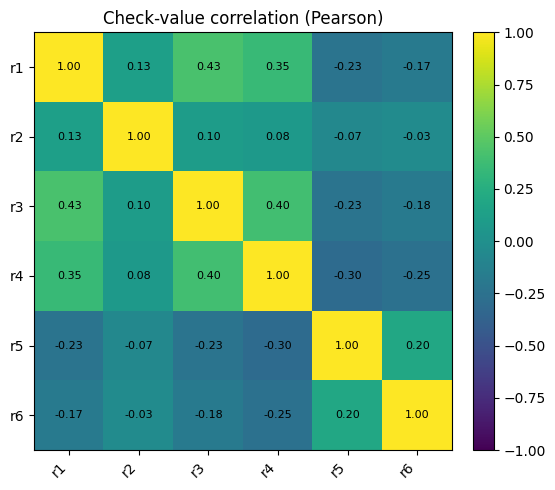

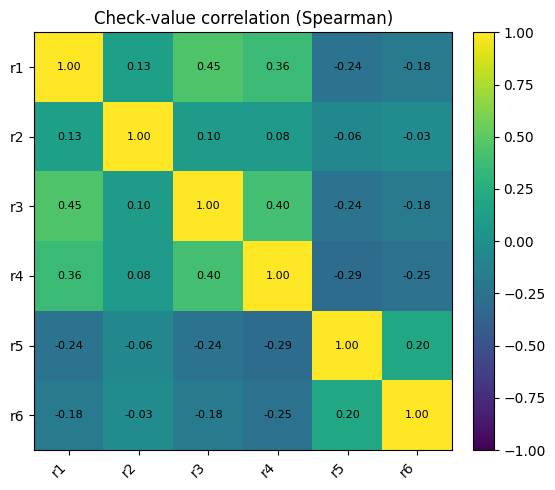

In [3]:
# ===== 0) imports =====
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _extract_int(s: str, default: int = 10**9) -> int:
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else default

def load_weekly(raw1_csv: str, id_col: str = "menti_seq", time_col: str = "reg_date"):
    df = pd.read_csv(raw1_csv)

    # 1) check*_value 우선
    check_val_cols = [c for c in df.columns if c.startswith("check") and c.endswith("_value")]
    check_val_cols = sorted(check_val_cols, key=_extract_int)

    # 2) 없으면 *_type 제외하고 check* 6개 선택
    if len(check_val_cols) == 0:
        cand = [c for c in df.columns if c.startswith("check")]
        cand = [c for c in cand if not c.endswith("_type")]
        cand = sorted(cand, key=_extract_int)[:6]
        check_val_cols = cand

    if len(check_val_cols) < 6:
        raise AssertionError(f"expect 6 check value columns, got {len(check_val_cols)}: {check_val_cols}")
    check_val_cols = check_val_cols[:6]

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df, check_val_cols, id_col, time_col


# ===== 1) 설정 =====
RAW1 = "data/raw_data1.csv"   # 네 경로에 맞게
ID_COL = "menti_seq"
TIME_COL = "reg_date"

# (옵션) 네 모델처럼 T=40만 쓰고 싶으면:
T = 40
USE_FIRST_T_ONLY = True

# 결측 처리 옵션
DROP_ANY_NA = True  # True면 check 6개 중 하나라도 NA면 그 row 제거


# ===== 2) 데이터 로드 + (선택) T주 제한 =====
df, check_cols, id_col, time_col = load_weekly(RAW1, id_col=ID_COL, time_col=TIME_COL)
print("check cols:", check_cols)
print("n_rows raw:", len(df), "n_patients:", df[id_col].nunique())

if USE_FIRST_T_ONLY:
    df = df.groupby(id_col, as_index=False, sort=False).head(T)
    print(f"after head(T={T}): n_rows:", len(df), "n_patients:", df[id_col].nunique())

# check 값만 뽑기
X = df[check_cols].copy()

# 결측 처리
if DROP_ANY_NA:
    before = len(X)
    X = X.dropna(axis=0, how="any")
    print("dropna rows:", before - len(X), "remain:", len(X))
else:
    # 결측을 중앙값으로 대체(원하면)
    X = X.fillna(X.median(numeric_only=True))

# numeric 변환
for c in check_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

# 다시 한 번 NA 제거(변환 실패 대비)
X = X.dropna(axis=0, how="any")
print("final rows used for corr:", len(X))


# ===== 3) 상관 계산 (Pearson / Spearman) =====
corr_pearson  = X.corr(method="pearson")
corr_spearman = X.corr(method="spearman")


# ===== 3.5) 표시용 라벨을 r1~r6로 변경 =====
r_labels = [f"r{i+1}" for i in range(len(check_cols))]

corr_pearson_plot = corr_pearson.copy()
corr_pearson_plot.columns = r_labels
corr_pearson_plot.index = r_labels

corr_spearman_plot = corr_spearman.copy()
corr_spearman_plot.columns = r_labels
corr_spearman_plot.index = r_labels


# ===== 4) 히트맵 그리기 유틸 =====
def plot_corr_heatmap(corr_df: pd.DataFrame, title: str, save_path: str = None):
    mat = corr_df.values
    labels = corr_df.columns.tolist()

    plt.figure(figsize=(6, 5))
    im = plt.imshow(mat, vmin=-1, vmax=1, interpolation="nearest")
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(np.arange(len(labels)), labels)

    # 셀에 값 표시(선택)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)
    plt.show()


# ===== 5) 실행: Pearson / Spearman 히트맵 =====
plot_corr_heatmap(corr_pearson_plot,  "Check-value correlation (Pearson)",  save_path="check_corr_pearson.png")
plot_corr_heatmap(corr_spearman_plot, "Check-value correlation (Spearman)", save_path="check_corr_spearman.png")


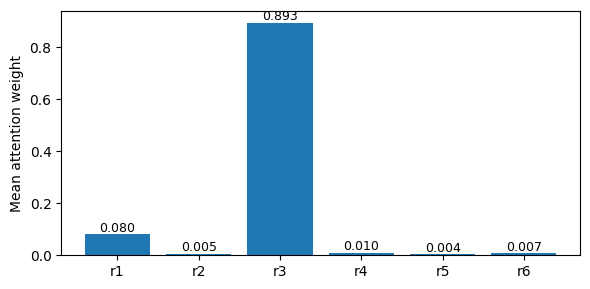

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# channel attention values
channels = ["r1", "r2", "r3", "r4", "r5", "r6"]
attn = [0.080332, 0.004563, 0.893357, 0.010219, 0.004262, 0.007268]

x = np.arange(len(channels))

plt.figure(figsize=(6, 3))
bars = plt.bar(x, attn)

plt.xticks(x, channels)
plt.ylabel("Mean attention weight")

# 값 표시 (논문용: 소수 3자리)
for b in bars:
    h = b.get_height()
    plt.text(
        b.get_x() + b.get_width() / 2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [9]:
!python approach3.py

[SERVICE] overall usage stats saved -> figs_phq_multi_attn/service_usage_overall_train.csv
    service  prop_used_week  ...  std_weeks_per_patient  prop_patients_any_use
0  service1        0.167125  ...              10.729027               0.666250
1  service2        0.084156  ...               8.524354               0.353125
2  service3        0.110578  ...              10.126652               0.343125
3  service4        0.082344  ...               8.758565               0.303125
4  service5        0.030391  ...               4.903864               0.193750

[5 rows x 5 columns]
[SERVICE] by y0_PHQ stats saved -> figs_phq_multi_attn/service_usage_by_y0PHQ_train.csv
[SERVICE] by ΔPHQ stats saved -> figs_phq_multi_attn/service_usage_by_dPHQ_train.csv
[EP01] train=0.8075  val=0.7021  (CEmean=0.7021)
[EP02] train=0.7340  val=0.6456  (CEmean=0.6456)
[EP03] train=0.6784  val=0.6049  (CEmean=0.6049)
[EP04] train=0.6421  val=0.5783  (CEmean=0.5783)
[EP05] train=0.6154  val=0.5644  (CEmean=0.5

In [11]:
from approach3 import build_dataset, SeqModelPHQ
import torch

# 1) 동일한 설정으로 batch 재구성
RAW1 = "data/raw_data1.csv"
RAW2 = "data/raw_data2.csv"
T = 40
SEED = 42

batch = build_dataset(
    RAW1, RAW2,
    T=T,
    outdir="figs_phq_multi_attn",
    seed=SEED
)

# 2) 모델 재생성 + weight 로드
levels = batch.levels.tolist()
device = batch.C.device

model = SeqModelPHQ(
    d_s=batch.S.size(-1),
    d_c=batch.C.size(-1),
    d_pos=16,
    hs=128,
    lambda_c=0.0,
    d_y0_each=16,
    use_y0_in_step=True,
    levels=levels,
    dropout=0.1,
).to(device)

ckpt = "figs_phq_multi_attn/best.pt"   # approach3에서 저장한 경로
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()


/tmp/ipykernel_970387/1785259427.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device))


SeqModelPHQ(
  (pos): Embedding(128, 16)
  (y0_emb_phq): Embedding(5, 16)
  (y0_emb_p4): Embedding(4, 16)
  (y0_emb_lon): Embedding(3, 16)
  (y0_to_h0): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): Tanh()
  )
  (ch_attn): Sequential(
    (0): Linear(in_features=182, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=6, bias=True)
  )
  (gru_cell): GRUCell(76, 128)
  (drop): Dropout(p=0.1, inplace=False)
  (attn_h): Linear(in_features=128, out_features=128, bias=False)
  (attn_y): Linear(in_features=48, out_features=128, bias=False)
  (attn_v): Linear(in_features=128, out_features=1, bias=False)
  (enc): Sequential(
    (0): Linear(in_features=176, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (head_phq): Linear(in_features=256, out_features=3, bias=True)
  (head_p4): Linear(in_features=256, out_features=3, bias=True)
  (head_lon): Linear(in_features=256, out_features=3

In [14]:
import numpy as np
import pandas as pd
import torch

import statsmodels.api as sm

def get_check3_index(batch):
    names = batch.stats.get("check_basenames", None)
    if names is None:
        cols = batch.stats.get("check_cols", [])
        names = [c.replace("_value", "") for c in cols]
    if "check3" not in names:
        raise ValueError("check3 not found")
    return names.index("check3")

def top_percent_mask(attn_row, pct):
    """
    attn_row: (T,)
    pct: 0.05, 0.10, ...
    """
    T = len(attn_row)
    k = max(1, int(np.ceil(T * pct)))
    idx = np.argsort(attn_row)[-k:]
    mask = np.zeros(T, dtype=bool)
    mask[idx] = True
    return mask

def restart_count(x):
    if len(x) <= 1:
        return 0
    return int(((x[:-1] == 0) & (x[1:] == 1)).sum())

@torch.no_grad()
def build_service_features_by_attention_percent(
    batch,
    model,
    split="train",
    percent_list=(0.05, 0.10, 0.15, 0.20, 0.25),
    include_controls=True,
):
    idx = batch.idx_tr if split == "train" else batch.idx_val

    S = batch.S[idx]          # (B,T,16)
    C = batch.C[idx]
    Craw = batch.Craw[idx]    # (B,T,6)

    y0p = batch.y0_phq[idx]
    y0p4 = batch.y0_p4[idx]
    y0lon = batch.y0_lon[idx]

    model.eval()
    _, _, _, attn, _ = model.forward_multi(S, C, y0p, y0p4, y0lon)

    S_np = S.cpu().numpy()
    Craw_np = Craw.cpu().numpy()
    attn_np = attn.cpu().numpy()

    service_cols = batch.stats["service_cols"]
    ch3 = get_check3_index(batch)

    # target: check3 improvement (1 -> 0)
    check3_first = Craw_np[:, 0, ch3]
    check3_last  = Craw_np[:, -1, ch3]
    y = ((check3_last - check3_first) == -1).astype(int)

    # controls
    service_total = (S_np > 0).sum(axis=(1,2))
    y0_PHQ = y0p.cpu().numpy()

    rows = []
    B, T, d_s = S_np.shape

    for i in range(B):
        row = {"improve_check3": int(y[i])}

        if include_controls:
            row["y0_PHQ"] = int(y0_PHQ[i])
            row["service_total"] = float(service_total[i])

        for pct in percent_list:
            mask = top_percent_mask(attn_np[i], pct)
            S_sel = (S_np[i, mask, :] > 0).astype(int)

            for j, sname in enumerate(service_cols):
                row[f"{sname}_int_p{int(pct*100)}"] = float(S_sel[:, j].sum())
                row[f"{sname}_rst_p{int(pct*100)}"] = float(restart_count(S_sel[:, j]))

        rows.append(row)

    return pd.DataFrame(rows)

def run_logit(df, pct, outdir="figs_check3_service"):
    import os
    os.makedirs(outdir, exist_ok=True)

    y = df["improve_check3"].values

    feat_cols = [c for c in df.columns if c.endswith(f"_p{int(pct*100)}")]
    ctrl_cols = [c for c in ["y0_PHQ", "service_total"] if c in df.columns]

    X = df[ctrl_cols + feat_cols].astype(float)

    # drop zero-variance
    X = X.loc[:, X.nunique() > 1]

    # standardize
    X = (X - X.mean()) / (X.std() + 1e-6)
    X = sm.add_constant(X)

    res = sm.Logit(y, X).fit_regularized(method="l1", alpha=1.0, disp=False)

    out = pd.DataFrame({
        "beta": res.params,
        "OR": np.exp(np.clip(res.params, -50, 50))
    })
    out.index.name = "feature"

    path = f"{outdir}/check3_OR_p{int(pct*100)}.csv"
    out.to_csv(path)
    print(f"[OK] saved -> {path}")

    return out


percent_list = [0.05, 0.10, 0.15, 0.20, 0.25]

df_train = build_service_features_by_attention_percent(
    batch=batch,
    model=model,
    split="train",
    percent_list=percent_list
)

for p in percent_list:
    run_logit(df_train, p)


[OK] saved -> figs_check3_service/check3_OR_p5.csv
[OK] saved -> figs_check3_service/check3_OR_p10.csv
[OK] saved -> figs_check3_service/check3_OR_p15.csv
[OK] saved -> figs_check3_service/check3_OR_p20.csv
[OK] saved -> figs_check3_service/check3_OR_p25.csv


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def run_logit_with_summary(df, pct, outdir="figs_check3_service", alpha_l1=1.0):
    """
    1) L1 regularized logit으로 변수 선택 
    2) 선택된 변수만으로 일반 Logit(MLE) 재적합 -> summary 출력
    """
    import os
    os.makedirs(outdir, exist_ok=True)

    y = df["improve_check3"].astype(int).values

    feat_cols = [c for c in df.columns if c.endswith(f"_p{int(pct*100)}")]
    ctrl_cols = [c for c in ["y0_PHQ", "service_total"] if c in df.columns]

    X = df[ctrl_cols + feat_cols].astype(float)

    # 0-variance 제거
    X = X.loc[:, X.nunique() > 1]

    # standardize
    Xz = (X - X.mean()) / (X.std() + 1e-6)
    Xz = sm.add_constant(Xz, has_constant="add")

    # --------------------------
    # Stage 1) L1 for selection
    # --------------------------
    res_l1 = sm.Logit(y, Xz).fit_regularized(method="l1", alpha=alpha_l1, disp=False)

    # 선택된 변수(계수 != 0), const는 유지
    selected = [name for name, b in res_l1.params.items() if (abs(b) > 1e-12)]
    if "const" not in selected:
        selected = ["const"] + selected

    # 너무 많이 남으면(혹은 너무 적게 남으면) 최소한의 방어
    if len(selected) <= 1:
        print(f"[WARN] pct={pct:.2f}: no feature selected (only const). Increase signal or lower alpha_l1.")
        return None, None, None

    # --------------------------
    # Stage 2) MLE for inference
    # --------------------------
    X2 = Xz[selected]
    res_mle = sm.Logit(y, X2).fit(disp=False, maxiter=300)

    # OR/CI/p 테이블
    params = res_mle.params
    bse = res_mle.bse
    pvals = res_mle.pvalues

    OR = np.exp(np.clip(params, -50, 50))
    OR_low = np.exp(np.clip(params - 1.96*bse, -50, 50))
    OR_high = np.exp(np.clip(params + 1.96*bse, -50, 50))

    out = pd.DataFrame({
        "beta": params,
        "OR": OR,
        "CI_low": OR_low,
        "CI_high": OR_high,
        "p_value": pvals
    })
    out.index.name = "feature"

    # save
    path = f"{outdir}/check3_OR_p{int(pct*100)}.csv"
    out.to_csv(path)
    print(f"[OK] pct={int(pct*100)}% saved -> {path}")

    # print summary
    print("\n==============================")
    print(f"Logit summary (top {int(pct*100)}% attention)")
    print("==============================")
    print(res_mle.summary())

    return out, res_mle, selected


In [18]:
percent_list = [0.05, 0.10, 0.15, 0.20, 0.25]

df_train = build_service_features_by_attention_percent(
    batch=batch,
    model=model,
    split="train",
    percent_list=percent_list
)

results = {}
for p in percent_list:
    out, res, selected = run_logit_with_summary(df_train, p, alpha_l1=1.0)
    results[p] = {"table": out, "model": res, "selected": selected}


/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


[OK] pct=5% saved -> figs_check3_service/check3_OR_p5.csv

Logit summary (top 5% attention)
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1600
Model:                          Logit   Df Residuals:                     1566
Method:                           MLE   Df Model:                           33
Date:                Wed, 28 Jan 2026   Pseudo R-squ.:                    -inf
Time:                        19:12:53   Log-Likelihood:                   -inf
converged:                      False   LL-Null:                       -861.63
Covariance Type:            nonrobust   LLR p-value:                     1.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             4.103e+09   4.37e+05   9390.662      0.000     4.1e+09     4.1e+09
y0_PHQ               

In [19]:
import os
import re
import glob
import numpy as np
import pandas as pd

OUTDIR = "figs_check3_service"

# 1) Load all check3_OR_p*.csv except p5
paths = sorted(glob.glob(os.path.join(OUTDIR, "check3_OR_p*.csv")))

rows = []
for p in paths:
    m = re.search(r"_p(\d+)\.csv$", p)
    if not m:
        continue
    pct = int(m.group(1))
    if pct == 5:
        continue

    df = pd.read_csv(p)
    # expected columns: feature,beta,OR,CI_low,CI_high,p_value,kind (maybe)
    df["pct"] = pct
    rows.append(df)

all_df = pd.concat(rows, ignore_index=True)

# 2) Basic cleaning
# - drop const if present
all_df = all_df[all_df["feature"].ne("const")].copy()

# - p-value numeric
all_df["p_value"] = pd.to_numeric(all_df["p_value"], errors="coerce")
all_df = all_df.dropna(subset=["p_value", "beta"])

# 3) Filter significant only (p < 0.05)
sig = all_df[all_df["p_value"] < 0.05].copy()

# 4) Effect size columns for sorting
sig["abs_beta"] = sig["beta"].abs()
sig["abs_logOR"] = np.log(sig["OR"].astype(float).clip(lower=1e-12)).abs()

# ---- Choose ONE sorting rule ----
# A) "영향력" = |beta| (추천: 표준화한 beta면 가장 직관적)
sig_sorted = sig.sort_values(["pct", "abs_beta"], ascending=[True, False])

# B) 만약 OR 기준으로 정렬하고 싶으면 아래로 바꿔:
# sig_sorted = sig.sort_values(["pct", "abs_logOR"], ascending=[True, False])

# 5) Show top-k per pct
TOPK = 20
for pct, g in sig_sorted.groupby("pct"):
    print(f"\n===== pct={pct}% | significant (p<0.05) top {TOPK} by |beta| =====")
    cols = ["pct","feature","beta","OR","CI_low","CI_high","p_value"]
    if "kind" in g.columns:
        cols.insert(2, "kind")
    print(g[cols].head(TOPK).to_string(index=False))

# 6) Save
out_path = os.path.join(OUTDIR, "check3_sig_sorted_excl_p5.csv")
sig_sorted.to_csv(out_path, index=False)
print(f"\n[OK] saved -> {out_path}")



===== pct=10% | significant (p<0.05) top 20 by |beta| =====
 pct           feature      beta       OR   CI_low  CI_high  p_value
  10     service_total  0.639226 1.895013 1.194186 3.007131 0.006662
  10  service6_int_p10 -0.254345 0.775424 0.621988 0.966710 0.023762
  10 service16_int_p10 -0.193176 0.824337 0.691364 0.982886 0.031371
  10 service11_rst_p10  0.192667 1.212479 1.034011 1.421749 0.017706
  10 service10_int_p10 -0.178230 0.836750 0.701740 0.997736 0.047117
  10            y0_PHQ  0.147508 1.158942 1.027942 1.306637 0.015939
  10  service8_rst_p10  0.131549 1.140594 1.003247 1.296744 0.044481

===== pct=15% | significant (p<0.05) top 20 by |beta| =====
 pct           feature      beta       OR   CI_low  CI_high  p_value
  15     service_total  0.550961 1.734920 1.040720 2.892179 0.034594
  15  service6_int_p15 -0.286019 0.751248 0.589580 0.957248 0.020701
  15 service15_int_p15 -0.220148 0.802400 0.648411 0.992959 0.042868
  15            y0_PHQ  0.152103 1.164280 1.033148

In [20]:
ser = pd.read_csv('figs_phq_multi_attn/service_logit_OR_top5_val.csv')
ser

,Unnamed: 0,OR,CI_low,CI_high,p_value
0,intercept,0.582971,0.000000,inf,9.995996e-01
1,service_total,0.687497,0.000000,inf,1.000000e+00
2,service1,1.225363,0.827462,1.814605,3.103173e-01
3,service2,1.197768,0.815437,1.759359,3.576139e-01
4,service3,1.384930,0.935344,2.050617,1.039043e-01
5,service4,0.988176,0.691644,1.411841,9.479003e-01
6,service5,0.898135,0.599116,1.346395,6.029917e-01
7,service6,1.101753,0.757494,1.602467,6.121827e-01
8,service7,1.487352,1.064603,2.077973,1.996885e-02
9,service8,1.285249,0.909908,1.815420,1.543891e-01


In [ ]:
ser = pd.read_csv('figs_phq_multi_attn/service_pair_OR_summary_val.csv')
ser

,feature,beta,OR,n_with,n_without,n_total,support,log_OR,composite_score,services,n_services,kind
0,service2+service9,1.379851,3.974309,35,365,400,0.0875,1.379851,0.120737,service2+service9,2,pair
1,service1,0.278030,1.320526,151,249,400,0.3775,0.278030,0.104957,service1,1,single
2,service3,0.456084,1.577882,90,310,400,0.2250,0.456084,0.102619,service3,1,single
3,service7,0.728363,2.071687,55,345,400,0.1375,0.728363,0.100150,service7,1,single
4,service4+service10,2.153542,8.615318,16,384,400,0.0400,2.153542,0.086142,service4+service10,2,pair
...,...,...,...,...,...,...,...,...,...,...,...,...
85,service13,-8.275477,0.000255,5,395,400,0.0125,-8.275477,-0.103443,service13,1,single
86,service6,-1.023256,0.359423,45,355,400,0.1125,-1.023256,-0.115116,service6,1,single
87,service10+service15,-7.638392,0.000482,7,393,400,0.0175,-7.638392,-0.133672,service10+service15,2,pair
88,service1+service6,-3.487440,0.030579,17,383,400,0.0425,-3.487440,-0.148216,service1+service6,2,pair


[SERVICE] patient-level explanations saved -> figs_phq_multi_attn/service_patient_explanations_top5_val.csv
[SERVICE-SEQ] per-patient features -> figs_phq_multi_attn/service_seq_features_val.csv
[SERVICE-SEQ] feature-wise OR + usage stats -> figs_phq_multi_attn/service_OR_seq_val.csv
[SERVICE-SEQ] top OR plot -> figs_phq_multi_attn/service_OR_seq_top20_val.png
[SERVICE-SEQ-ATTN] per-patient features -> figs_phq_multi_attn/service_seq_features_highattn_val.csv
[SERVICE-SEQ-ATTN] feature-wise OR (any vs high-attn) -> figs_phq_multi_attn/service_OR_seq_highattn_val.csv
[SAVE] pair/sequence OR summary -> figs_phq_multi_attn/service_pair_OR_summary_val.csv

In [22]:
ser = pd.read_csv('figs_phq_multi_attn/service_OR_seq_highattn_val.csv')
ser

,feature,beta_any,OR_any,n_with_any,n_total,support_any,beta_high,OR_high,n_with_high,support_high,log_OR_any,composite_any,log_OR_high,composite_high
0,service3,0.282042,1.325835,150,400,0.3750,0.323601,1.382095,81.0,0.2025,0.282042,0.105766,0.323601,0.065529
1,service3+service9,-0.007642,0.992387,91,400,0.2275,0.546872,1.727840,38.0,0.0950,-0.007642,-0.001739,0.546872,0.051953
2,service2,0.136198,1.145908,144,400,0.3600,0.275044,1.316589,70.0,0.1750,0.136198,0.049031,0.275044,0.048133
3,service2+service9,0.294142,1.341975,82,400,0.2050,0.580345,1.786654,32.0,0.0800,0.294142,0.060299,0.580345,0.046428
4,service2+service3,0.369848,1.447514,55,400,0.1375,0.516720,1.676519,31.0,0.0775,0.369848,0.050854,0.516720,0.040046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,service9+service15,-0.253786,0.775858,40,400,0.1000,-1.047337,0.350871,14.0,0.0350,-0.253786,-0.025379,-1.047337,-0.036657
129,service15+service16,-0.796385,0.450956,23,400,0.0575,-1.823372,0.161480,9.0,0.0225,-0.796385,-0.045792,-1.823372,-0.041026
130,service9+service10,-0.247737,0.780565,160,400,0.4000,-0.157636,0.854161,107.0,0.2675,-0.247737,-0.099095,-0.157636,-0.042168
131,service10+service14,-0.078349,0.924642,17,400,0.0425,-8.242404,0.000263,5.0,0.0125,-0.078349,-0.003330,-8.242404,-0.103030


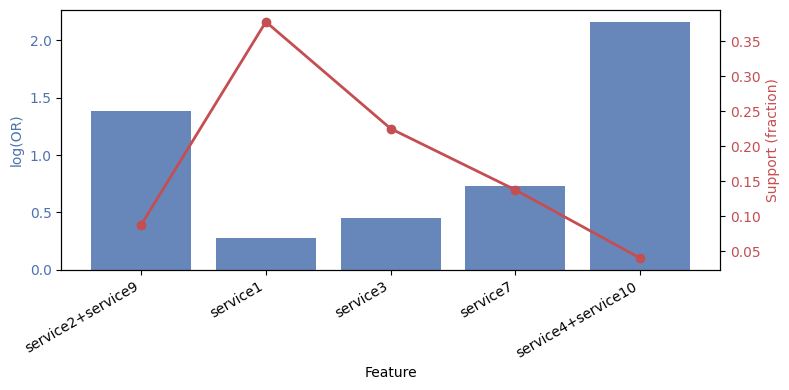

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ser = pd.read_csv('figs_phq_multi_attn/service_pair_OR_summary_val.csv')

# 상위 5개: composite_score 기준
df = (
    ser[['feature', 'log_OR', 'support', 'composite_score']]
    .sort_values('composite_score', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

x = range(len(df))

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left y-axis: log(OR) — bar
bar_color = '#4C72B0'  # muted blue
ax1.bar(x, df['log_OR'], color=bar_color, alpha=0.85)
ax1.set_ylabel('log(OR)', color=bar_color)
ax1.tick_params(axis='y', labelcolor=bar_color)

ax1.set_xlabel('Feature')
ax1.set_xticks(list(x))
ax1.set_xticklabels(df['feature'], rotation=30, ha='right')

# Right y-axis: Support — line
line_color = '#C44E52'  # muted red
ax2 = ax1.twinx()
ax2.plot(list(x), df['support'], marker='o', color=line_color, linewidth=2)
ax2.set_ylabel('Support (fraction)', color=line_color)
ax2.tick_params(axis='y', labelcolor=line_color)

plt.tight_layout()
plt.show()


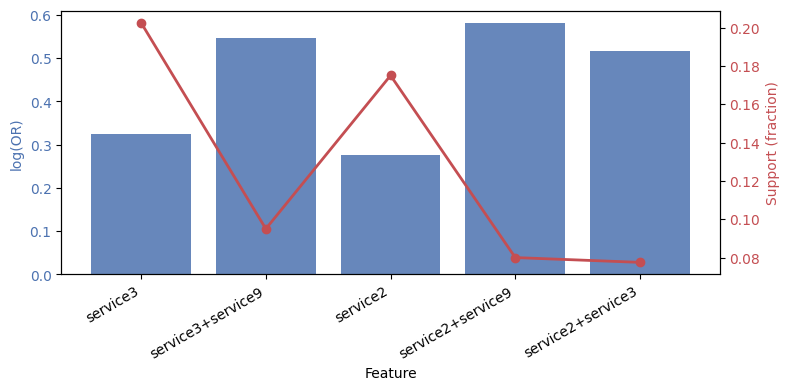

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

ser = pd.read_csv('figs_phq_multi_attn/service_OR_seq_highattn_val.csv')
# 상위 5개: composite_high 기준
df = (
    ser[['feature', 'log_OR_high', 'support_high', 'composite_high']]
    .sort_values('composite_high', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

x = range(len(df))

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left y-axis: log(OR) — bar
bar_color = '#4C72B0'  # muted blue
ax1.bar(x, df['log_OR_high'], color=bar_color, alpha=0.85)
ax1.set_ylabel('log(OR)', color=bar_color)
ax1.tick_params(axis='y', labelcolor=bar_color)

ax1.set_xlabel('Feature')
ax1.set_xticks(list(x))
ax1.set_xticklabels(df['feature'], rotation=30, ha='right')

# Right y-axis: Support — line
line_color = '#C44E52'  # muted red
ax2 = ax1.twinx()
ax2.plot(list(x), df['support_high'], marker='o', color=line_color, linewidth=2)
ax2.set_ylabel('Support (fraction)', color=line_color)
ax2.tick_params(axis='y', labelcolor=line_color)

plt.tight_layout()
plt.show()


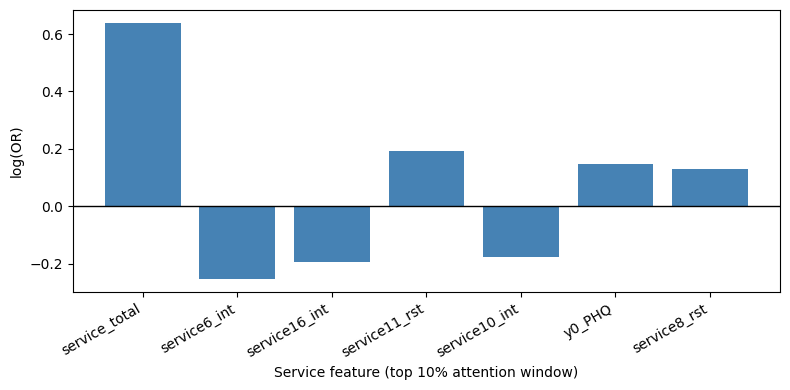

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "feature": [
        "service_total",
        "service6_int",
        "service16_int",
        "service11_rst",
        "service10_int",
        "y0_PHQ",
        "service8_rst",
    ],
    "OR": [
        1.895013,
        0.775424,
        0.824337,
        1.212479,
        0.836750,
        1.158942,
        1.140594,
    ]
})

df["log_OR"] = np.log(df["OR"])

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    df["feature"],
    df["log_OR"],
    color="steelblue"
)

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("log(OR)")
ax.set_xlabel("Service feature (top 10% attention window)")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
